# IML PROJECT

## Gerekliliklerin Yüklenmesi

In [5]:
%pip install pandas
%pip install numpy 
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

df = pd.read_csv('TUANDROMD.csv')
print("Veri seti başarıyla yüklendi.")

Veri seti başarıyla yüklendi.


## 1. Veri Keşfi ve İstatistiksel Analiz
Bu bölümde veri setinin genel yapısını, eksik verileri ve sınıf dağılımını inceliyoruz.

In [7]:
# 2. Genel Bakış
print(f"Gözlem Sayısı: {df.shape[0]}")  # En az 1000 olmalı
print(f"Özellik Sayısı: {df.shape[1]}")  # En az 20 olmalı
print("-" * 30)
print(df.info())  # Veri tipleri ve eksik değer kontrolü

print("\nİlk 5 Satır:")
display(df.head()) # Jupyter'de 'display' daha güzel tablo gösterir

# İstatistiksel Özet
print("\nİstatistiksel Özet (İlk 20 Özellik):")
display(df.describe().T.head(20))

# Benzersiz Değer Kontrolü
print("\nSütun Bazında Benzersiz Değer Sayıları (İlk 10):")
print(df.nunique().head(10))

# Label dağılımı
print("\nLabel Dağılımı:")
counts = df['Label'].value_counts()
percentages = df['Label'].value_counts(normalize=True) * 100

for label, count in counts.items():
    print(f"{label}: {count} örnek ({percentages[label]:.2f}%)")

Gözlem Sayısı: 4465
Özellik Sayısı: 242
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(241), object(1)
memory usage: 8.2+ MB
None

İlk 5 Satır:


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware



İstatistiksel Özet (İlk 20 Özellik):


,count,mean,std,min,25%,50%,75%,max
ACCESS_ALL_DOWNLOADS,4464.0,0.000896,0.029924,0.0,0.0,0.0,0.0,1.0
ACCESS_CACHE_FILESYSTEM,4464.0,0.000896,0.029924,0.0,0.0,0.0,0.0,1.0
ACCESS_CHECKIN_PROPERTIES,4464.0,0.004928,0.070037,0.0,0.0,0.0,0.0,1.0
ACCESS_COARSE_LOCATION,4464.0,0.083333,0.276416,0.0,0.0,0.0,0.0,1.0
ACCESS_COARSE_UPDATES,4464.0,0.006944,0.083053,0.0,0.0,0.0,0.0,1.0
ACCESS_FINE_LOCATION,4464.0,0.087814,0.283055,0.0,0.0,0.0,0.0,1.0
ACCESS_LOCATION_EXTRA_COMMANDS,4464.0,0.022849,0.149440,0.0,0.0,0.0,0.0,1.0
ACCESS_MOCK_LOCATION,4464.0,0.023746,0.152272,0.0,0.0,0.0,0.0,1.0
ACCESS_MTK_MMHW,4464.0,0.000224,0.014967,0.0,0.0,0.0,0.0,1.0
ACCESS_NETWORK_STATE,4464.0,0.596326,0.490689,0.0,0.0,1.0,1.0,1.0



Sütun Bazında Benzersiz Değer Sayıları (İlk 10):
ACCESS_ALL_DOWNLOADS              2
ACCESS_CACHE_FILESYSTEM           2
ACCESS_CHECKIN_PROPERTIES         2
ACCESS_COARSE_LOCATION            2
ACCESS_COARSE_UPDATES             2
ACCESS_FINE_LOCATION              2
ACCESS_LOCATION_EXTRA_COMMANDS    2
ACCESS_MOCK_LOCATION              2
ACCESS_MTK_MMHW                   2
ACCESS_NETWORK_STATE              2
dtype: int64

Label Dağılımı:
malware: 3565 örnek (79.86%)
goodware: 899 örnek (20.14%)


## 2. Veri Ön İşleme
Eksik verilerin kontrolü, Label Encoding işlemi ve Eğitim/Test ayrımı (Train-Test Split).

Toplam Eksik Değer: 242
Eksik veriler temizlendi.
Sınıf Eşleşmeleri: {'goodware': np.int64(0), 'malware': np.int64(1)}

Eğitim Seti: 3571 örnek
Test Seti: 893 örnek


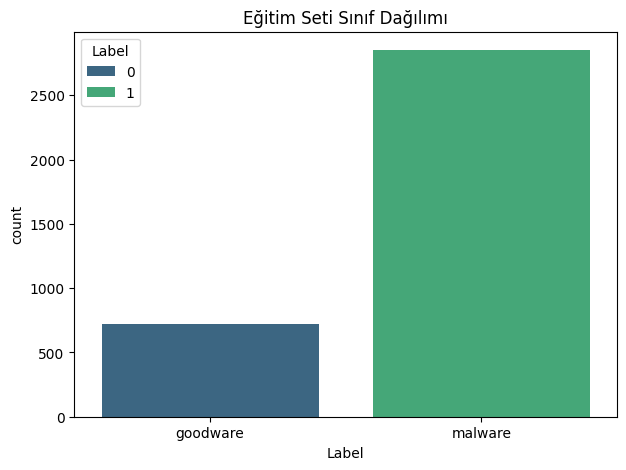

In [8]:
# Eksik değer kontrolü
missing_values = df.isnull().sum().sum()
print(f"Toplam Eksik Değer: {missing_values}")

# Eksik değer içeren satırları silme (Varsa)
if missing_values > 0:
    df.dropna(inplace=True)
    print("Eksik veriler temizlendi.")

# Label Encoding
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Sınıf Eşleşmeleri: {mapping}")

X = df.drop('Label', axis=1)
y = df['Label']

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nEğitim Seti: {X_train.shape[0]} örnek")
print(f"Test Seti: {X_test.shape[0]} örnek")

# Sınıf Dağılımı Grafiği
plt.figure(figsize=(7, 5))
sns.countplot(x=y_train, hue=y_train, palette='viridis')
plt.title('Eğitim Seti Sınıf Dağılımı')
plt.xticks(ticks=[0, 1], labels=le.classes_)
plt.show()

## 3. Özellik Seçimi (Feature Selection)
Model performansını artırmak ve işlem yükünü azaltmak için:
1. **Variance Threshold:** Sabit özellikleri atma.
2. **Korelasyon Filtresi:** Birbiriyle çok ilişkili özellikleri atma.
3. **Mutual Information:** Hedef değişkenle en alakalı özellikleri seçme.

In [9]:
# A. Sabit Özellikler (Variance Threshold)
selector = VarianceThreshold(threshold=0.01)
X_train_v = selector.fit_transform(X_train)
kept_cols = X_train.columns[selector.get_support()]
print(f"Düşük varyans nedeniyle silinen özellik sayısı: {X_train.shape[1] - len(kept_cols)}")

X_train_filtered = X_train[kept_cols].copy()

# B. Yüksek Korelasyon Filtresi
def remove_highly_correlated(data, threshold=0.9):
    corr_matrix = data.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return to_drop

dropped_corr_cols = remove_highly_correlated(X_train_filtered, threshold=0.9)
print(f"Çok yüksek korelasyon (%90+) nedeniyle silinen özellik sayısı: {len(dropped_corr_cols)}")
X_train_filtered.drop(columns=dropped_corr_cols, inplace=True)

# C. Mutual Information (Bilgi Kazancı)
importances = mutual_info_classif(X_train_filtered, y_train, random_state=42)
feature_info = pd.Series(importances, index=X_train_filtered.columns).sort_values(ascending=False)

# En iyi özellikleri seçme
selected_features = feature_info.head(60).index.tolist()
top_20_features = feature_info.head(20).index.tolist()
top_2_features = feature_info.head(2).index.tolist()

# FİNAL VERİ SETLERİNİN OLUŞTURULMASI
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

print(f"Final Özellik Sayısı: {len(selected_features)}")

Düşük varyans nedeniyle silinen özellik sayısı: 140
Çok yüksek korelasyon (%90+) nedeniyle silinen özellik sayısı: 31
Final Özellik Sayısı: 60


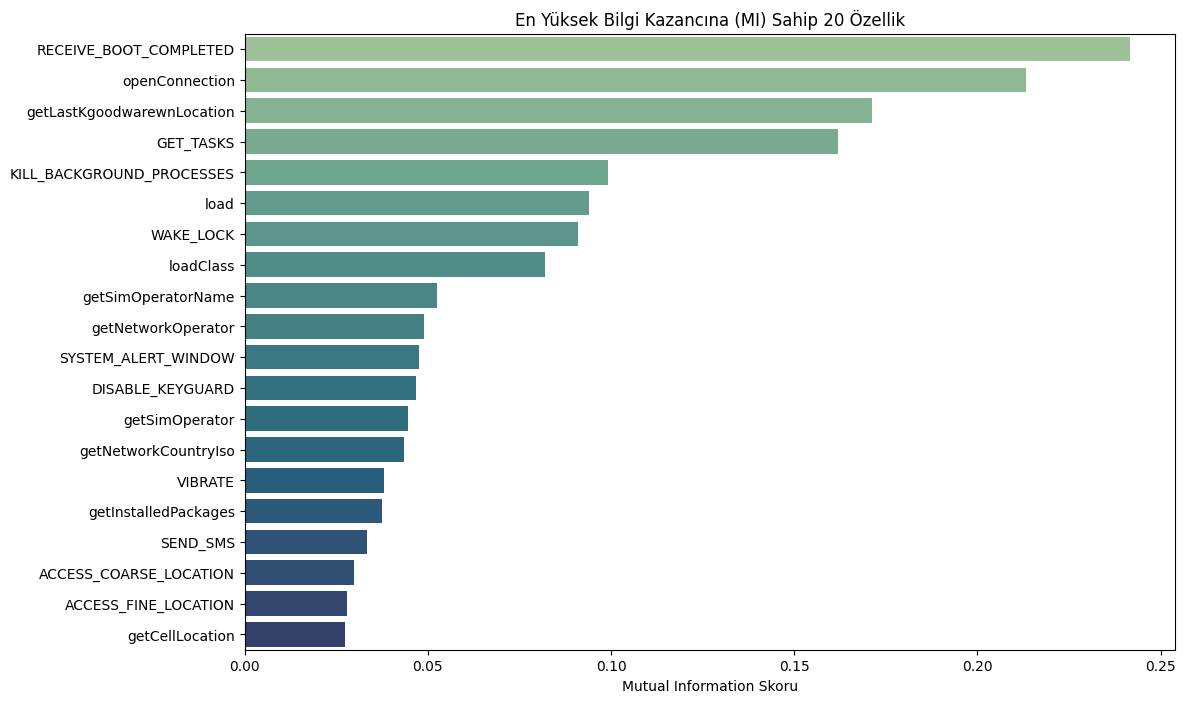

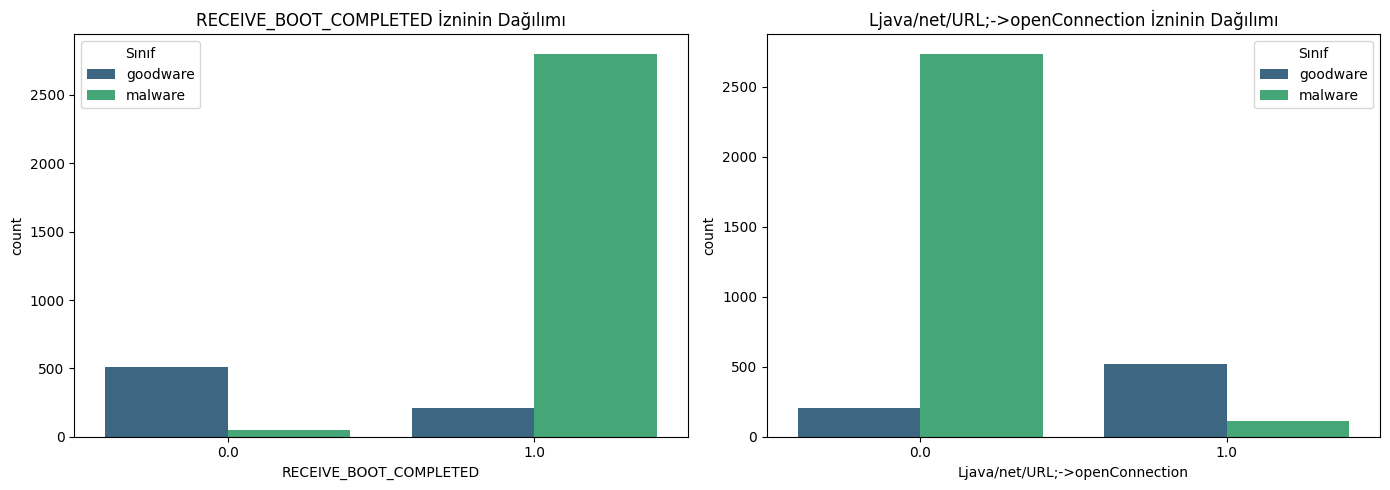

Korelasyon Haritası Oluşturuluyor...


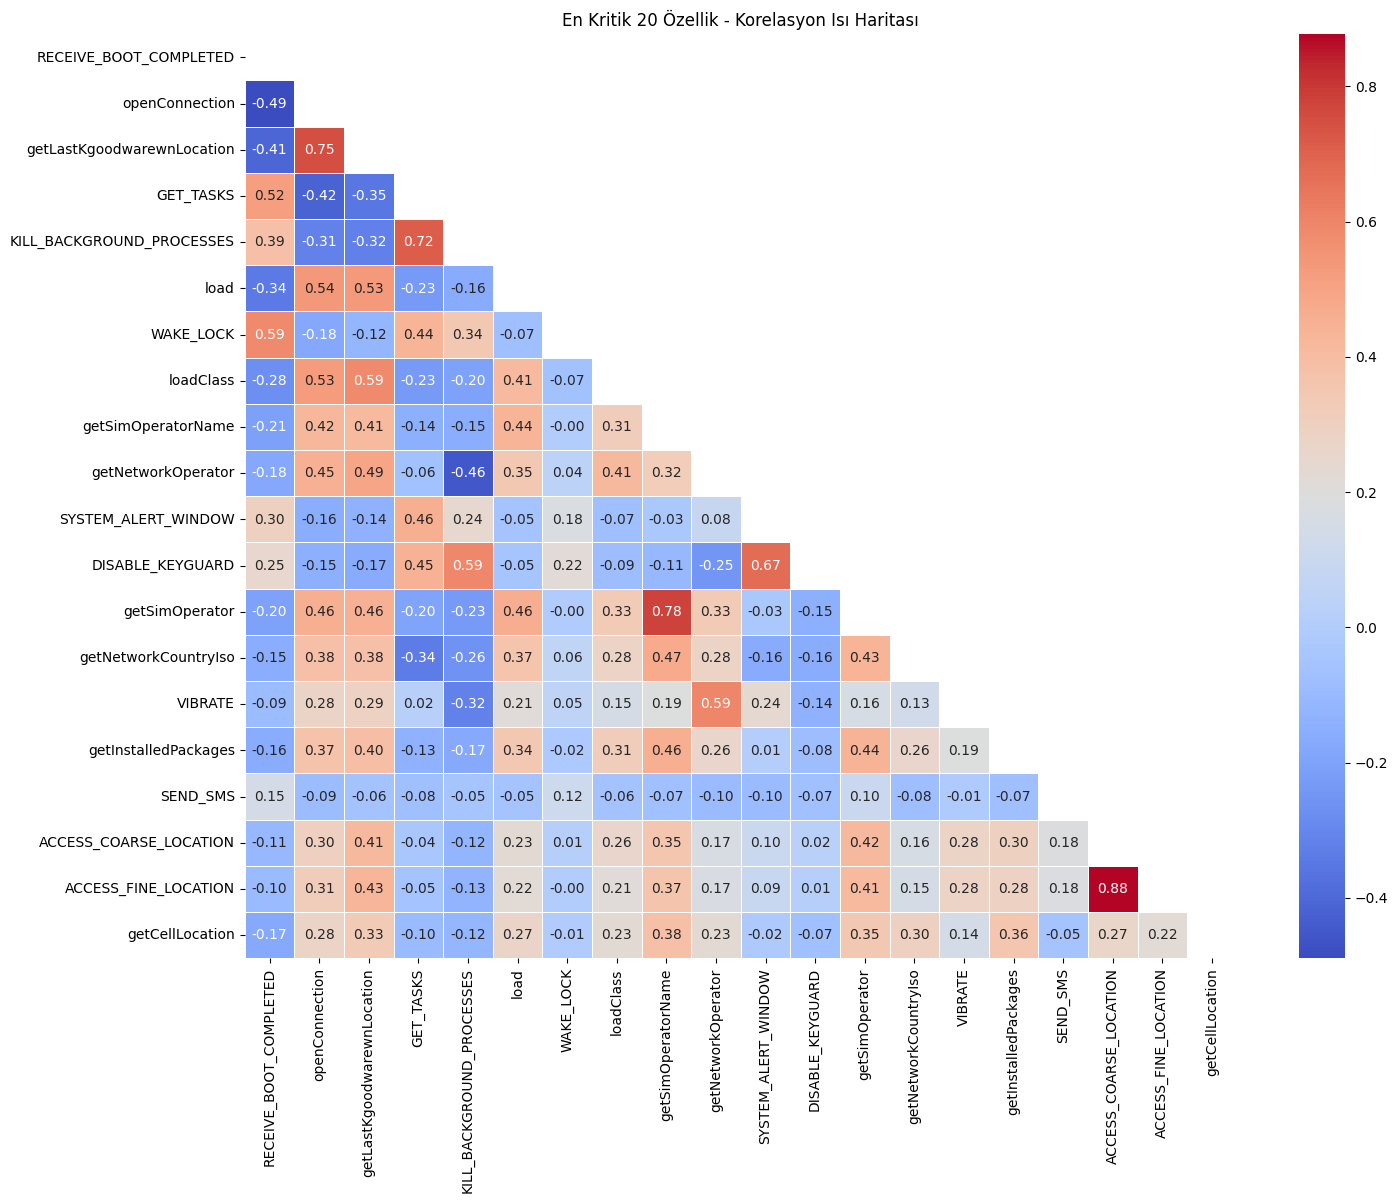

In [10]:
# Mutual Information Barplot
clean_names = [name.split('.')[-1].split('->')[-1] for name in feature_info.head(20).index]

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_info.head(20).values, y=clean_names, hue=clean_names, palette='crest', legend=False)
plt.title('En Yüksek Bilgi Kazancına (MI) Sahip 20 Özellik')
plt.xlabel('Mutual Information Skoru')
plt.show()

# En Etkili 2 Özelliğin Dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(top_2_features):
    sns.countplot(x=X_train[col], hue=y_train, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} İzninin Dağılımı')
    axes[i].legend(title='Sınıf', labels=list(mapping.keys()))
plt.tight_layout()
plt.show()

# Korelasyon Heatmap
print("Korelasyon Haritası Oluşturuluyor...")
short_names = [name.split('.')[-1].split('->')[-1] for name in top_20_features]
correlation_matrix = X_train[top_20_features].corr()
correlation_matrix.index = short_names
correlation_matrix.columns = short_names

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('En Kritik 20 Özellik - Korelasyon Isı Haritası')
plt.show()

## 4. Modelleme ve Hiperparametre Optimizasyonu
Bu aşamada 3 farklı yaklaşım izlenecektir:
1. **Baseline Model:** Dummy Classifier (Referans noktası).
2. **Logistic Regression:** Temel sınıflandırma modeli.
3. **Random Forest:** GridSearchCV ile optimize edilmiş (tuned) model.

--- Baseline (Dummy) Model Sonuçları ---
              precision    recall  f1-score   support

    goodware       0.00      0.00      0.00       180
     malware       0.80      1.00      0.89       713

    accuracy                           0.80       893
   macro avg       0.40      0.50      0.44       893
weighted avg       0.64      0.80      0.71       893



c:\Users\demir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\demir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\demir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

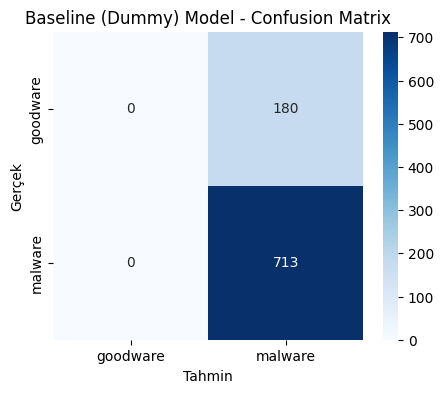

--- Logistic Regression Sonuçları ---
              precision    recall  f1-score   support

    goodware       0.97      0.97      0.97       180
     malware       0.99      0.99      0.99       713

    accuracy                           0.99       893
   macro avg       0.98      0.98      0.98       893
weighted avg       0.99      0.99      0.99       893



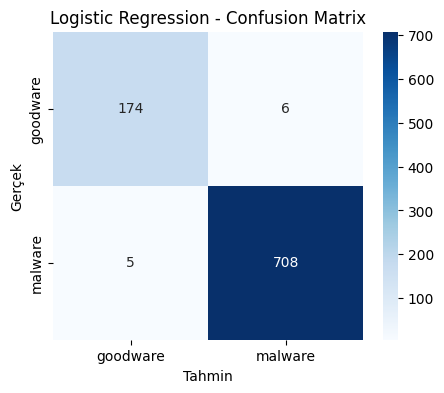

Random Forest Tuning Başlıyor...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

En İyi Parametreler: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
--- Random Forest (Tuned) Sonuçları ---
              precision    recall  f1-score   support

    goodware       0.99      0.98      0.99       180
     malware       1.00      1.00      1.00       713

    accuracy                           0.99       893
   macro avg       0.99      0.99      0.99       893
weighted avg       0.99      0.99      0.99       893



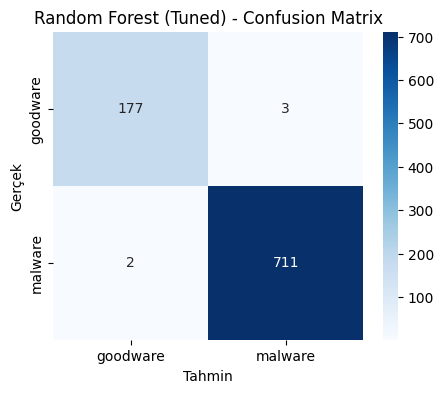

In [11]:
# Değerlendirme Fonksiyonu
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"--- {model_name} Sonuçları ---")
    print(classification_report(y_test, y_pred, target_names=list(mapping.keys())))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(mapping.keys()), yticklabels=list(mapping.keys()))
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.show()
    return f1_score(y_test, y_pred, average='weighted')

# 1. Baseline Model
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_final, y_train)
dummy_score = evaluate_model(dummy_clf, X_test_final, y_test, "Baseline (Dummy) Model")

# 2. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_final, y_train)
log_score = evaluate_model(log_reg, X_test_final, y_test, "Logistic Regression")

# 3. Random Forest + Tuning
print("Random Forest Tuning Başlıyor...")
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train)

best_rf_model = grid_search.best_estimator_
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")
rf_score = evaluate_model(best_rf_model, X_test_final, y_test, "Random Forest (Tuned)")

## 5. Sonuçların Karşılaştırılması ve Analiz
Modellerin performans kıyaslaması, özellik önem düzeyleri (Feature Importance) ve Overfitting kontrolü.

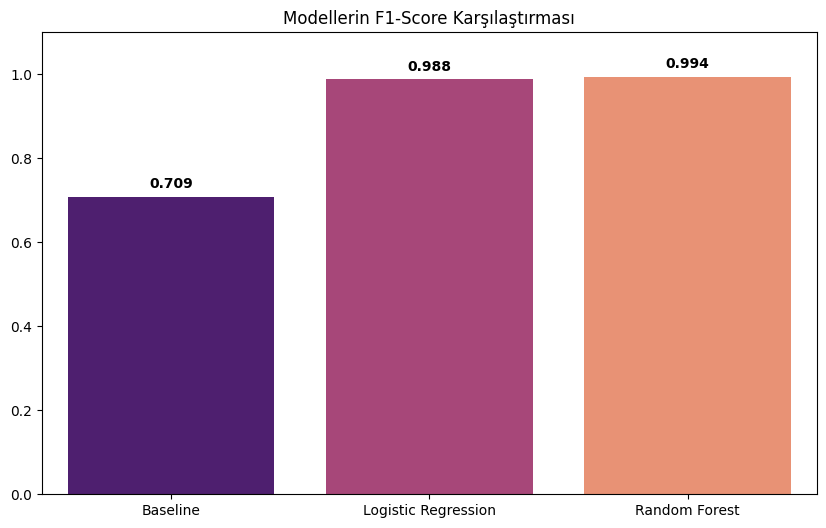

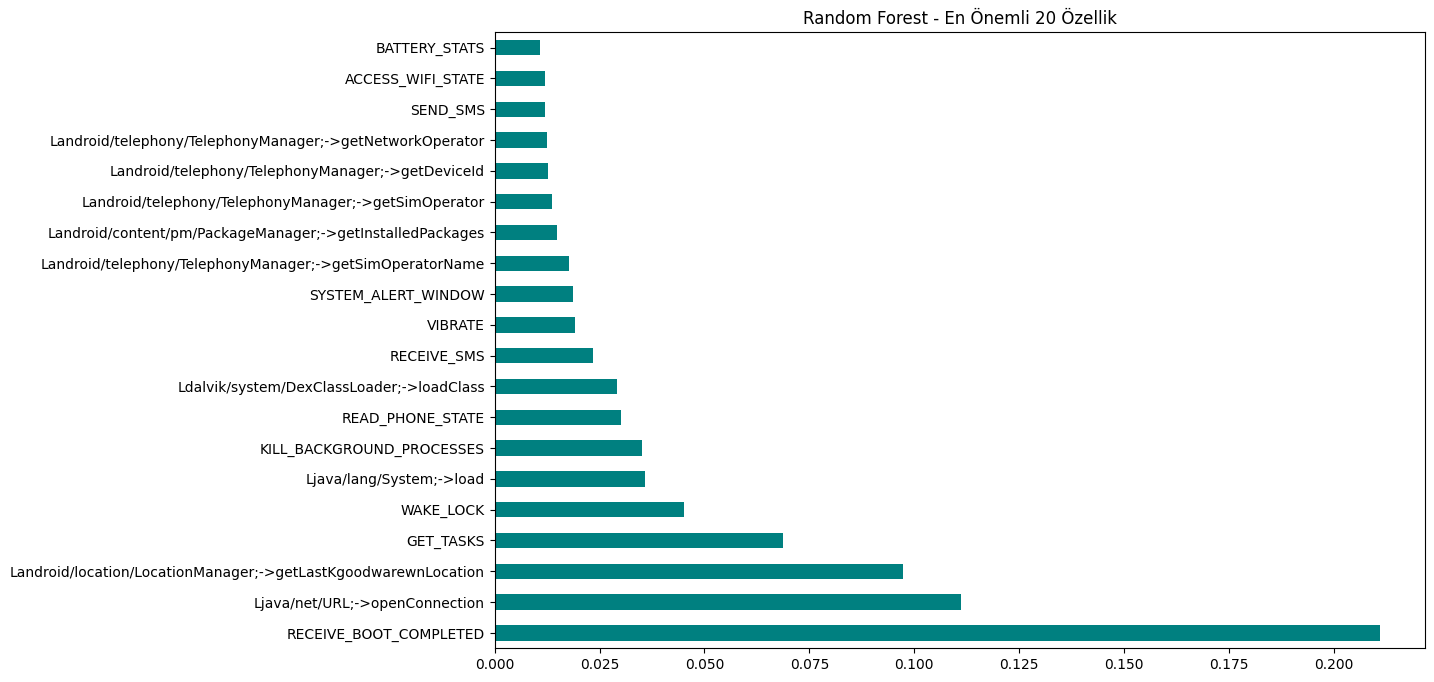

--- Random Forest Overfitting Analizi ---
Eğitim Skoru: 0.9925
Test Skoru:   0.9944
Fark:         -0.0019
------------------------------
--- Logistic Regression Overfitting Analizi ---
Eğitim Skoru: 0.9841
Test Skoru:   0.9877
Fark:         -0.0035
------------------------------


In [12]:
# Model Karşılaştırma Grafiği
models = ['Baseline', 'Logistic Regression', 'Random Forest']
scores = [dummy_score, log_score, rf_score]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=scores, hue=models, palette='magma', legend=False)
plt.title('Modellerin F1-Score Karşılaştırması')
plt.ylim(0, 1.1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# Feature Importance
if 'Random Forest' in models[2]:
    plt.figure(figsize=(12, 8))
    feat_importances = pd.Series(best_rf_model.feature_importances_, index=X_train_final.columns)
    feat_importances.nlargest(20).plot(kind='barh', color='teal')
    plt.title('Random Forest - En Önemli 20 Özellik')
    plt.show()

# Overfitting Kontrolü
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Model"):
    y_pred_train = model.predict(X_train)
    train_score = f1_score(y_train, y_pred_train, average='weighted')
    
    y_pred_test = model.predict(X_test)
    test_score = f1_score(y_test, y_pred_test, average='weighted')
    
    print(f"--- {model_name} Overfitting Analizi ---")
    print(f"Eğitim Skoru: {train_score:.4f}")
    print(f"Test Skoru:   {test_score:.4f}")
    print(f"Fark:         {train_score - test_score:.4f}")
    print("-" * 30)

check_overfitting(best_rf_model, X_train_final, y_train, X_test_final, y_test, "Random Forest")
check_overfitting(log_reg, X_train_final, y_train, X_test_final, y_test, "Logistic Regression")